In [1]:
import pandas as pd

# Kaggle training data: one row per house sold in Ames, Iowa (2006-2010)
# the notebook sits in notebooks/, so "../" goes up one folder to reach data/
df = pd.read_csv("../data/train.csv")

# (rows, columns) -> rows are houses, columns are features + SalePrice
print(df.shape)

# first 5 houses, just to see what the data looks like
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**What I see**

- 1460 houses and 81 columns: Id, 79 features and SalePrice (the target).
- Mix of number columns (LotArea, LotFrontage, PoolArea) and text columns (MSZoning, Street, LotShape).
- MSSubClass looks like a number but it's a house-type code (20 = 1-story 1946+, 60 = 2-story 1946+). Treat it as a category, not a number.
- Alley, PoolQC, Fence, MiscFeature are NaN for these houses. Per data_description.txt, NA here means "no alley / no pool / no fence", so it's not really missing. Fill with "None" later.
- LotFrontage shows decimals (65.0), so it probably has real missing values. Check with df.info().
- Id is just a row number. Drop it before modelling.

In [2]:
# column name, how many non-empty values it has, and its type
# int/float = numbers, object = text
# any count below 1460 means that column has NaN somewhere
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [3]:
# count NaN in every column, biggest first
missing = df.isna().sum().sort_values(ascending=False)

# drop the columns that have no NaN at all
missing = missing[missing > 0]

# as a % of all 1460 houses, so columns are easy to compare
missing_pct = (missing / len(df) * 100).round(1)

print(len(missing), "columns have NaN")
missing_pct

19 columns have NaN


PoolQC          99.5
MiscFeature     96.3
Alley           93.8
Fence           80.8
MasVnrType      59.7
FireplaceQu     47.3
LotFrontage     17.7
GarageQual       5.5
GarageFinish     5.5
GarageType       5.5
GarageYrBlt      5.5
GarageCond       5.5
BsmtFinType2     2.6
BsmtExposure     2.6
BsmtCond         2.5
BsmtQual         2.5
BsmtFinType1     2.5
MasVnrArea       0.5
Electrical       0.1
dtype: float64

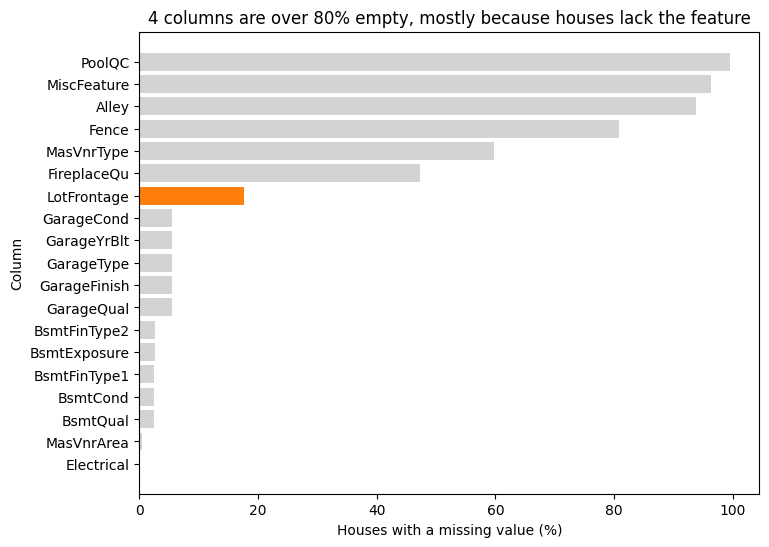

In [4]:
import matplotlib.pyplot as plt

# barh draws bottom-up, so sort small to big to get the biggest bar on top
plot_data = missing_pct.sort_values()

# orange = truly unknown value, grey = NaN just means "house doesn't have it"
colors = ["tab:orange" if col == "LotFrontage" else "lightgrey" for col in plot_data.index]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(plot_data.index, plot_data.values, color=colors)
ax.set_title("4 columns are over 80% empty, mostly because houses lack the feature")
ax.set_xlabel("Houses with a missing value (%)")
ax.set_ylabel("Column")
plt.show()


### Explore the data

In [5]:
# SalePrice is what we predict, in US dollars
# mean vs median tells us early if the prices are lopsided
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

**What I see**
- Prices go from about $35k to $755k.
- Mean (~$181k) is higher than the median ($163k), so a few expensive houses pull the average up.

### Histogram of the target

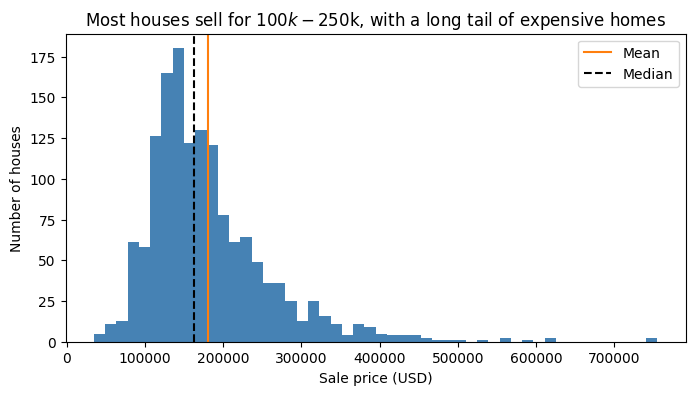

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["SalePrice"], bins=50, color="steelblue")

# lines for mean and median, to show the gap between them
ax.axvline(df["SalePrice"].mean(), color="tab:orange", label="Mean")
ax.axvline(df["SalePrice"].median(), color="black", linestyle="--", label="Median")

ax.set_title("Most houses sell for $100k-$250k, with a long tail of expensive homes")
ax.set_xlabel("Sale price (USD)")
ax.set_ylabel("Number of houses")
ax.legend()
plt.show()

**What I see**
- Right-skewed: a big hump on the left and a long thin tail to the right.
- Linear models work better when the target is closer to a bell shape. This is the reason to try a log transform.

### Measure the skew, before and after log

In [7]:
import numpy as np

# skew = 0 means balanced; above 1 means a long right tail
# log1p = log(1 + x); it squeezes big values more than small ones
print("Skew before log:", round(df["SalePrice"].skew(), 2))
print("Skew after log: ", round(np.log1p(df["SalePrice"]).skew(), 2))

Skew before log: 1.88
Skew after log:  0.12


**What I see**
- Skew drops from about 1.88 to about 0.12 after the log, so it's almost balanced.
- Bonus: Kaggle scores this competition with RMSE on log price, so a log target matches how the model is judged.

### Histogram after log

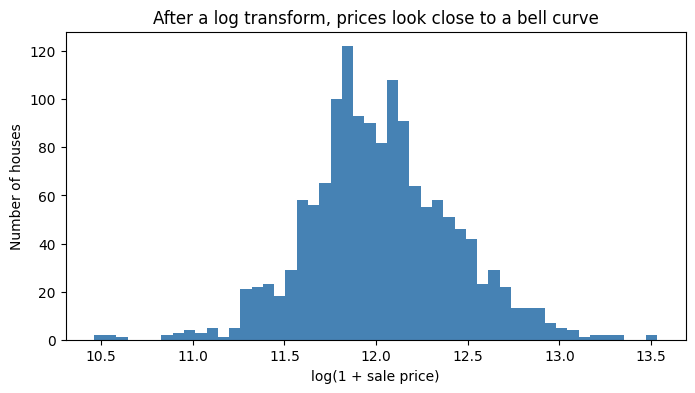

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(df["SalePrice"]), bins=50, color="steelblue")
ax.set_title("After a log transform, prices look close to a bell curve")
ax.set_xlabel("log(1 + sale price)")
ax.set_ylabel("Number of houses")
plt.show()

**What I see**
- The long tail is gone. The shape is roughly symmetric.
- Decision: the models will predict log price, and I convert back to dollars with np.expm1 at the end.

### Which number columns move with price?

In [9]:
# correlation of every number column with SalePrice (-1 to +1)
# drop SalePrice itself, since it always correlates 1.0 with itself
corr = df.select_dtypes("number").corr()["SalePrice"].drop("SalePrice")
corr.sort_values(ascending=False).head(10)

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

### Bar chart of the top 10

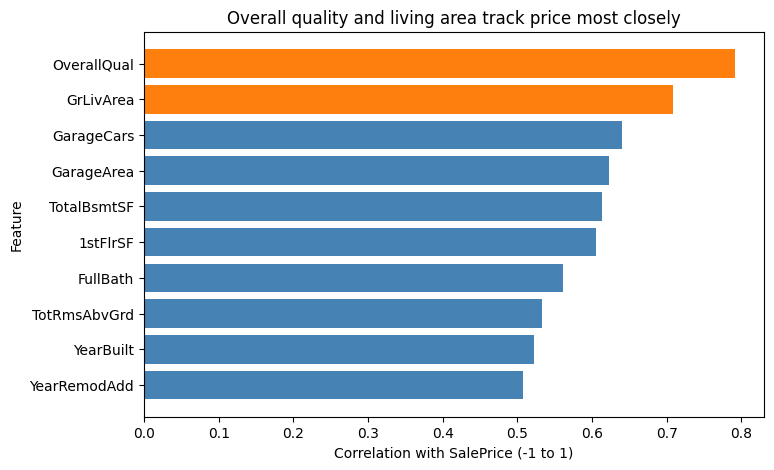

In [10]:
# biggest on top, and orange for the two strongest
top10 = corr.sort_values(ascending=False).head(10).sort_values()
colors = ["tab:orange" if v > 0.7 else "steelblue" for v in top10.values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10.index, top10.values, color=colors)
ax.set_title("Overall quality and living area track price most closely")
ax.set_xlabel("Correlation with SalePrice (-1 to 1)")
ax.set_ylabel("Feature")
plt.show()

**What I see**
- OverallQual (~0.79) and GrLivArea (~0.71) are the strongest.
- GarageCars and GarageArea are both high, but they say the same thing (bigger garage). Same for TotalBsmtSF and 1stFlrSF. Pairs like this are called multicollinearity; Ridge handles them better than plain linear regression.

### Scatter plot, living area vs price

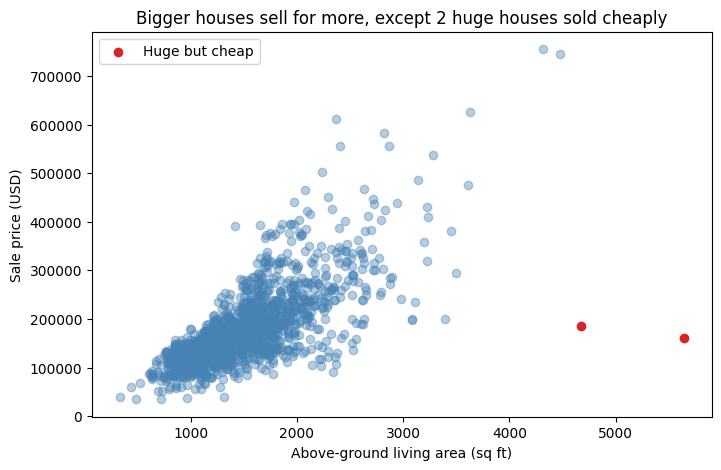

In [11]:
# very large houses that sold cheap; the dataset's author recommends removing them
odd = (df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df.loc[~odd, "GrLivArea"], df.loc[~odd, "SalePrice"], alpha=0.4, color="steelblue")
ax.scatter(df.loc[odd, "GrLivArea"], df.loc[odd, "SalePrice"], color="tab:red", label="Huge but cheap")
ax.set_title("Bigger houses sell for more, except 2 huge houses sold cheaply")
ax.set_xlabel("Above-ground living area (sq ft)")
ax.set_ylabel("Sale price (USD)")
ax.legend()
plt.show()

In [12]:
# check what makes them odd before deciding to drop them
df.loc[odd, ["Id", "GrLivArea", "SalePrice", "SaleCondition", "Neighborhood"]]

,Id,GrLivArea,SalePrice,SaleCondition,Neighborhood
523,524,4676,184750,Partial,Edwards
1298,1299,5642,160000,Partial,Edwards


**What I see**
- Clear upward trend: more living area, higher price.
- 2 houses above 4000 sq ft sold far below the trend. Their SaleCondition explains why they're unusual sales.
- Decision: remove these 2 rows before training, because they would pull the line down for all big houses.

### Box plot, price by quality grade

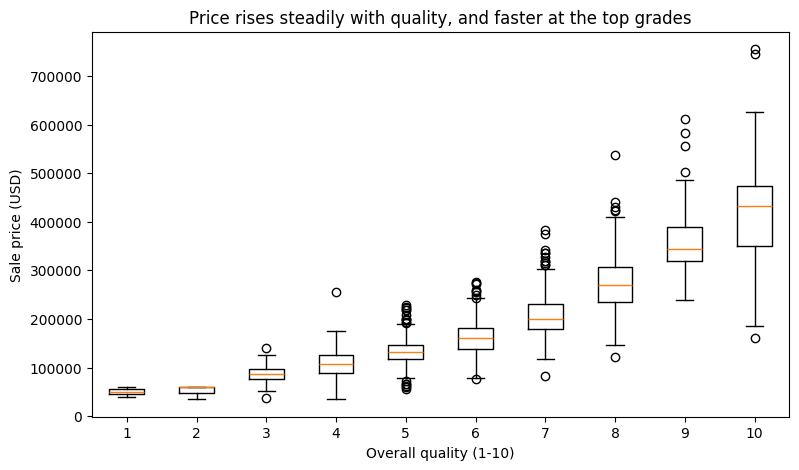

In [13]:
# one box of prices for each quality grade (1 = very poor, 10 = very excellent)
levels = sorted(df["OverallQual"].unique())
groups = [df.loc[df["OverallQual"] == q, "SalePrice"] for q in levels]

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(groups, tick_labels=levels)
ax.set_title("Price rises steadily with quality, and faster at the top grades")
ax.set_xlabel("Overall quality (1-10)")
ax.set_ylabel("Sale price (USD)")
plt.show()

### Median price by neighbourhood

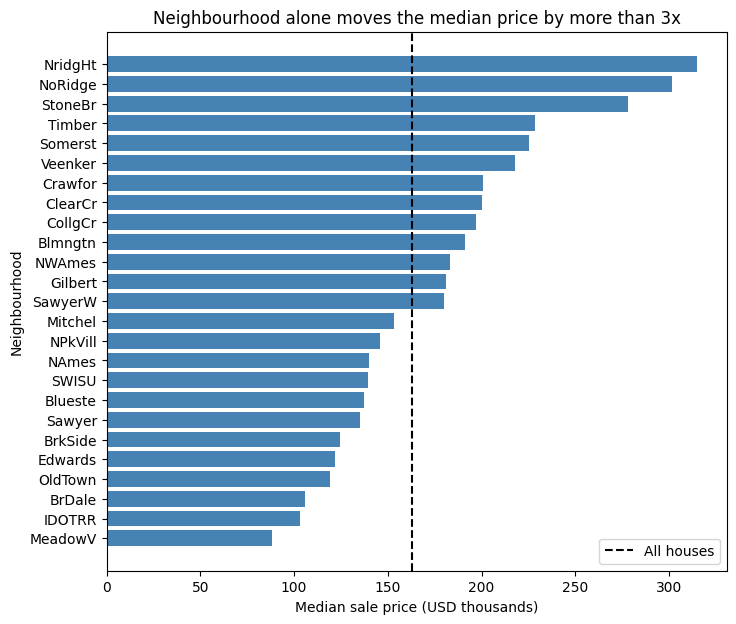

In [14]:
# median, not mean, so a few mansions don't distort a neighbourhood
nbhd = df.groupby("Neighborhood")["SalePrice"].median().sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(nbhd.index, nbhd.values / 1000, color="steelblue")
ax.axvline(df["SalePrice"].median() / 1000, color="black", linestyle="--", label="All houses")
ax.set_title("Neighbourhood alone moves the median price by more than 3x")
ax.set_xlabel("Median sale price (USD thousands)")
ax.set_ylabel("Neighbourhood")
ax.legend()
plt.show()

**What I see**
- Quality: each step up adds more money than the step before, which fits a log target.
- Neighbourhood: MeadowV is the cheapest, NridgHt/NoRidge the most expensive. Location matters even for similar houses, so Neighborhood must go into the model as a category.

### Clean the data

In [15]:
# work on a copy so the raw df stays untouched
data = df.copy()

# the 2 huge-but-cheap houses found in Cell 11
data = data[~odd]

# Id is just a row number, it says nothing about price
data = data.drop(columns="Id")
print(data.shape)

(1458, 80)


In [16]:
# NaN that means "the house doesn't have it"
# per data_description.txt, NA in these columns means no pool, no garage, no basement etc.
none_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
             "GarageType", "GarageFinish", "GarageQual", "GarageCond",
             "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
             "MasVnrType"]

# turn "missing" into a real category the model can learn from
data[none_cols] = data[none_cols].fillna("None")

In [17]:
# Two number columns
# no masonry veneer means an area of 0
data["MasVnrArea"] = data["MasVnrArea"].fillna(0)

# GarageYrBlt is NaN when there's no garage, and 0 would be a fake year
# it's also almost the same as YearBuilt, so drop it
data = data.drop(columns="GarageYrBlt")

In [18]:
# MSSubClass is a code, not a number
# 20, 60, 70... are house-type codes, so store them as text
# otherwise the model thinks 60 is "3 times" 20
data["MSSubClass"] = data["MSSubClass"].astype(str)

### What's still missing?

In [19]:
# what's left will be filled inside the pipeline, using training data only
left = data.isna().sum()
left[left > 0]

LotFrontage    259
Electrical       1
dtype: int64

**What I see**
- Only 2 columns still have gaps: LotFrontage (truly unknown lot width) and Electrical (1 house).
- These need a learned value (median / most common), so they get filled in the pipeline after the train/test split. That avoids data leakage.

### Separate features and target

In [20]:
# X = what the model sees, y = what it predicts
# y is log price, based on the skew check in Cell 7
X = data.drop(columns="SalePrice")
y = np.log1p(data["SalePrice"])
print(X.shape, y.shape)

(1458, 78) (1458,)


### Train/test split

In [21]:
from sklearn.model_selection import train_test_split

# keep 20% aside to test on houses the model has never seen
# random_state=42 gives the same split every run, so results are repeatable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(1166, 78) (292, 78)


In [22]:
# Which columns are numbers, which are text
# the pipeline treats these two groups differently
num_cols = X_train.select_dtypes("number").columns
cat_cols = X_train.select_dtypes("object").columns
print(len(num_cols), "number columns,", len(cat_cols), "text columns")

34 number columns, 44 text columns


In [23]:
# The preparation steps
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# numbers: fill gaps with the median (e.g. LotFrontage), then put all on the same scale
num_steps = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

# text: fill gaps with the most common value (e.g. Electrical), then one-hot
# handle_unknown="ignore": a category never seen in training won't crash the model
cat_steps = make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore"))

prep = make_column_transformer((num_steps, num_cols), (cat_steps, cat_cols))

### Models

In [24]:


from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# baseline always predicts the average price, and every real model must beat it
# alpha = how strongly Ridge/Lasso shrink the coefficients (tuned properly in Stage 4)
models = {
    "Baseline (mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=10)": Ridge(alpha=10),
    "Lasso (alpha=0.001)": Lasso(alpha=0.001, max_iter=50000),
}

In [25]:
# Compare with 5-fold cross-validation


from sklearn.model_selection import cross_val_score

results = {}
for name, model in models.items():
    pipe = make_pipeline(prep, model)
    # sklearn returns negative RMSE (higher = better), so flip the sign
    scores = -cross_val_score(pipe, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")
    results[name] = scores.mean()
    print(f"{name}: RMSE {scores.mean():.3f} (+/- {scores.std():.3f})")

Baseline (mean): RMSE 0.397 (+/- 0.018)
Linear Regression: RMSE 0.129 (+/- 0.012)
Ridge (alpha=10): RMSE 0.114 (+/- 0.009)
Lasso (alpha=0.001): RMSE 0.115 (+/- 0.013)


### Chart the comparison

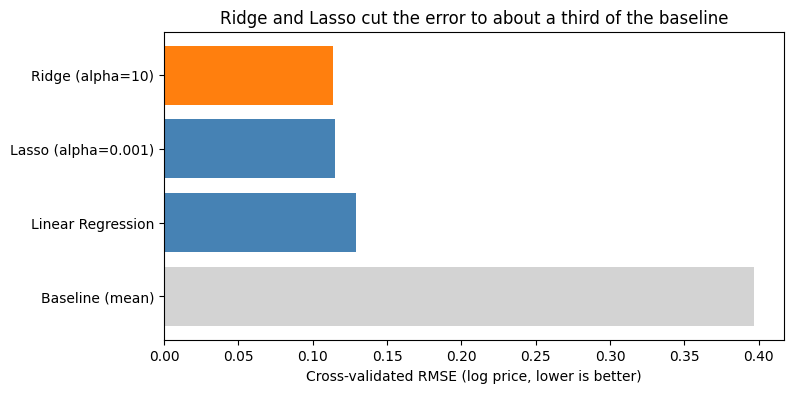

In [26]:
# lowest error on top; orange = best model, grey = baseline
res = pd.Series(results).sort_values(ascending=False)
colors = ["tab:orange" if v == res.min() else "lightgrey" if "Baseline" in k else "steelblue"
          for k, v in res.items()]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(res.index, res.values, color=colors)
ax.set_title("Ridge and Lasso cut the error to about a third of the baseline")
ax.set_xlabel("Cross-validated RMSE (log price, lower is better)")
plt.show()

**What I see**
- Every model beats the baseline by a wide margin, so the features really carry information about price.
- Ridge and Lasso are better and more stable than plain Linear Regression. With ~300 one-hot columns and 1166 houses, plain regression overfits; the penalty keeps coefficients small.
- An RMSE of ~0.12 on log price means predictions are typically about 12% off.

### Tune and evaluate


In [27]:
# Tune Ridge


from sklearn.model_selection import GridSearchCV

# try several penalty strengths; each is scored with 5-fold CV on training data
ridge_alphas = [0.1, 1, 3, 10, 30, 100]
ridge_pipe = make_pipeline(prep, Ridge())

# make_pipeline names the model step "ridge", so the setting is "ridge__alpha"
ridge_grid = GridSearchCV(ridge_pipe, {"ridge__alpha": ridge_alphas}, cv=5, scoring="neg_root_mean_squared_error")
ridge_grid.fit(X_train, y_train)
print("Best alpha:", ridge_grid.best_params_["ridge__alpha"], "| CV RMSE:", round(-ridge_grid.best_score_, 4))

Best alpha: 30 | CV RMSE: 0.1134


In [28]:
# Tune Lasso


# Lasso needs much smaller alphas than Ridge on this data
lasso_alphas = [0.0001, 0.0003, 0.0005, 0.001, 0.003, 0.01]
lasso_pipe = make_pipeline(prep, Lasso(max_iter=50000))

lasso_grid = GridSearchCV(lasso_pipe, {"lasso__alpha": lasso_alphas}, cv=5, scoring="neg_root_mean_squared_error")
lasso_grid.fit(X_train, y_train)
print("Best alpha:", lasso_grid.best_params_["lasso__alpha"], "| CV RMSE:", round(-lasso_grid.best_score_, 4))

Best alpha: 0.0005 | CV RMSE: 0.1134


In [29]:
# Features kept by Lasso

# fitted steps inside the tuned Lasso pipeline: [0] = prep, [-1] = the model
lasso_model = lasso_grid.best_estimator_
names = lasso_model[0].get_feature_names_out()
coefs = pd.Series(lasso_model[-1].coef_, index=names)

# names look like "pipeline-1__GrLivArea"; keep only the part after "__"
coefs.index = coefs.index.str.split("__").str[1]
print("Features kept:", (coefs != 0).sum(), "of", len(coefs))

Features kept: 115 of 311


**What I see**
- Ridge (alpha=30) and Lasso (alpha=0.0005) both reach CV RMSE 0.1134, so predictions are typically ~11% off.
- Neither best alpha is at the edge of its search list, so the range was wide enough.
- Lasso keeps 115 of 311 features. Same accuracy with fewer features, so I choose Lasso.
- I made this choice before looking at the test set, so the test score stays honest.

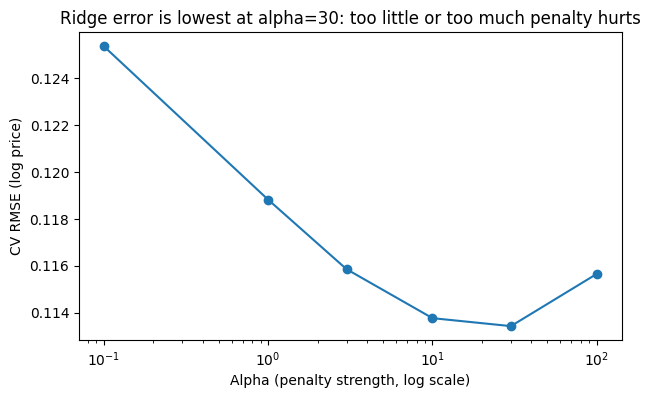

In [30]:
# Error vs alpha (Ridge)

# mean CV error for each alpha, in the same order as the list
ridge_rmse = -ridge_grid.cv_results_["mean_test_score"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ridge_alphas, ridge_rmse, marker="o")
ax.set_xscale("log")   # alphas jump 0.1 -> 100, so a log axis spaces them evenly
ax.set_title("Ridge error is lowest at alpha=30: too little or too much penalty hurts")
ax.set_xlabel("Alpha (penalty strength, log scale)")
ax.set_ylabel("CV RMSE (log price)")
plt.show()




**What I see**
- The error falls from ~0.125 (alpha 0.1) to ~0.113 (alpha 10-30), then rises to ~0.116 at alpha 100: a U-shape.
- Too little penalty overfits, too much underfits. This is the bias-variance trade-off.
- The bottom is flat between 10 and 30, so the exact alpha doesn't matter much there.
- The y-axis is zoomed in; the full gain from tuning is about 1 percentage point of error.

### Test the chosen model once

In [31]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# Ridge and Lasso tied on CV RMSE (0.1134); 
# Lasso chosen because it keeps 115 of 311 features
best = lasso_grid

# predict log price, then convert back to dollars for a readable error
pred_log = best.predict(X_test)
price_true, price_pred = np.expm1(y_test), np.expm1(pred_log)

print("Test RMSE (log):", round(root_mean_squared_error(y_test, pred_log), 4))
print("Test MAE ($):   ", round(mean_absolute_error(price_true, price_pred)))
print("Test R2:        ", round(r2_score(y_test, pred_log), 3))

Test RMSE (log): 0.1161
Test MAE ($):    13844
Test R2:         0.92


**What I see**
- Test RMSE 0.1161 vs CV RMSE 0.1134: almost the same, so the model generalizes to unseen houses.
- Average miss is about $13.8k per house, roughly 8-9% of the median price ($163k).
- R2 = 0.92 on log price.

### Actual vs predicted prices

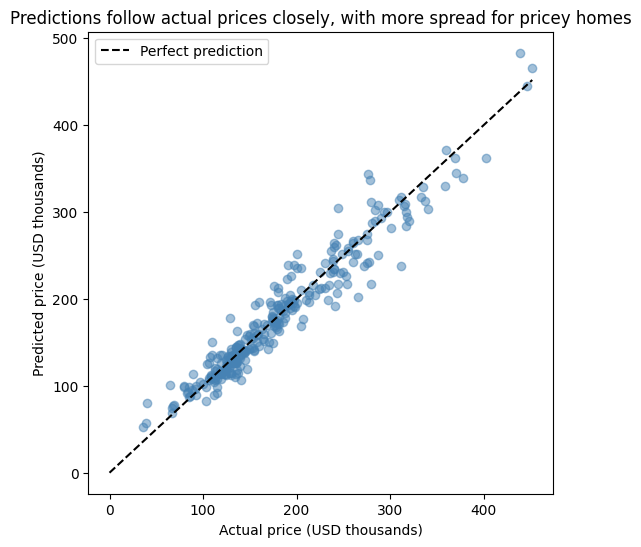

In [32]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(price_true / 1000, price_pred / 1000, alpha=0.5, color="steelblue")

# perfect predictions would sit exactly on this line
lims = [0, price_true.max() / 1000]
ax.plot(lims, lims, color="black", linestyle="--", label="Perfect prediction")
ax.set_title("Predictions follow actual prices closely, with more spread for pricey homes")
ax.set_xlabel("Actual price (USD thousands)")
ax.set_ylabel("Predicted price (USD thousands)")
ax.legend()
plt.show()

**What I see**

- Dots follow the perfect-prediction line closely, especially under $200k.
  
- Spread grows with price. Expected with a log target: errors are similar in %, so they're bigger in dollars for expensive homes.
- Misses fall on both sides of the line, so there's no systematic over- or under-pricing.
- A few big misses (~$60-70k) around  $275-310k, and the cheapest houses are predicted slightly high.

### Residuals: is there any pattern left?

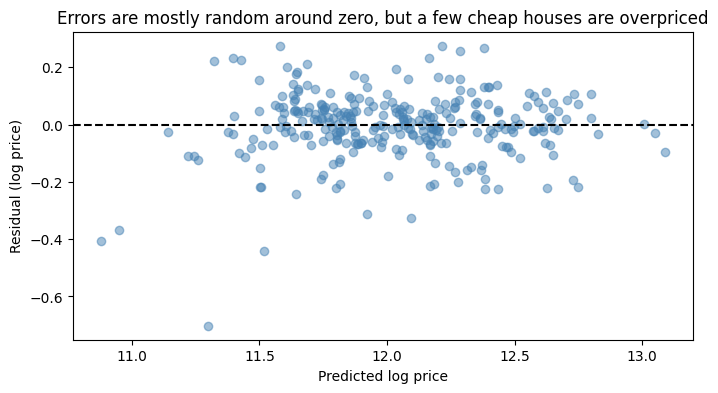

In [33]:
# residual = actual - predicted (in log price); a good model leaves random noise around 0
residuals = y_test - pred_log

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(pred_log, residuals, alpha=0.5, color="steelblue")
ax.axhline(0, color="black", linestyle="--")
ax.set_title("Errors are mostly random around zero, but a few cheap houses are overpriced")
ax.set_xlabel("Predicted log price")
ax.set_ylabel("Residual (log price)")
plt.show()

**What I see**
- Most residuals sit randomly between -0.2 and +0.2, with no curve or funnel, so the linear model on log price fits most houses well.
- The biggest misses are all negative (overpriced) and mostly at the low-price end. The worst is -0.7: that house sold for about half the predicted price.
- Next step: check what these houses have in common.

### The houses the model got most wrong

In [34]:
# the 5 test houses with the biggest error (either direction)
worst = residuals.abs().sort_values(ascending=False).head(5).index

# a few columns that might explain the miss, plus actual vs predicted in dollars
check = X_test.loc[worst, ["Neighborhood", "OverallQual", "GrLivArea", "SaleCondition"]].copy()
check["Actual $"] = price_true.loc[worst].round()
check["Predicted $"] = pd.Series(price_pred, index=y_test.index).loc[worst].round()
check

,Neighborhood,OverallQual,GrLivArea,SaleCondition,Actual $,Predicted $
30,IDOTRR,4,1317,Normal,40000.0,80738.0
1432,OldTown,4,968,Normal,64500.0,100426.0
916,IDOTRR,2,480,Abnorml,35311.0,53055.0
533,BrkSide,1,334,Normal,39300.0,56889.0
666,NAmes,6,2380,Abnorml,129000.0,178469.0


**What I see**
- All 5 worst misses are overpriced, and 4 of them sold for under $65k: low quality (1-4), very small, in older neighbourhoods.
- Only 2 of 5 are abnormal sales, so sale type explains some misses, not most.
- The model is weakest at the very low end: few cheap houses to learn from, and regularization pulls extreme predictions toward the average.
- In real use, I'd flag very low-quality houses and abnormal sales for a human check instead of trusting the price.

### Does a tree model do better? (XGBoost)

In [35]:
from xgboost import XGBRegressor

# many small trees, each fixing the errors of the ones before it (gradient boosting)
# settings are sensible defaults, not tuned yet
xgb = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=3,
                   subsample=0.8, colsample_bytree=0.8, random_state=42)

# same pipeline, same 5 folds, same metric as Ridge and Lasso, so it's a fair comparison
xgb_pipe = make_pipeline(prep, xgb)
scores = -cross_val_score(xgb_pipe, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")
print(f"XGBoost CV RMSE: {scores.mean():.4f} (+/- {scores.std():.4f})")

XGBoost CV RMSE: 0.1206 (+/- 0.0120)


### Tuning XGBoost once

In [36]:
# try 3 tree depths x 3 learning rates = 9 combinations, each checked with 5-fold CV
# make_pipeline names the model step "xgbregressor", hence the "xgbregressor__" prefix
xgb_params = {
    "xgbregressor__max_depth": [2, 3, 4],
    "xgbregressor__learning_rate": [0.03, 0.05, 0.1],
}

xgb_grid = GridSearchCV(xgb_pipe, xgb_params, cv=5, scoring="neg_root_mean_squared_error")
xgb_grid.fit(X_train, y_train)
print("Best settings:", xgb_grid.best_params_)
print("Tuned XGBoost CV RMSE:", round(-xgb_grid.best_score_, 4))

Best settings: {'xgbregressor__learning_rate': 0.05, 'xgbregressor__max_depth': 2}
Tuned XGBoost CV RMSE: 0.1184


**What I see**
- Tuned XGBoost (depth 2, learning rate 0.05): CV RMSE 0.1184. Better than untuned (0.1206), still worse than Lasso (0.1134).
- The rule set before tuning was "switch only if below 0.110", so I keep Lasso.
- The best depth was the smallest one tried (2): simpler trees did better, which suggests price depends on features in mostly simple, additive ways. That's exactly what a linear model captures.
- Depth 1 was not tried, so this is a limit of the search, noted for next steps.

### Which features drive the price

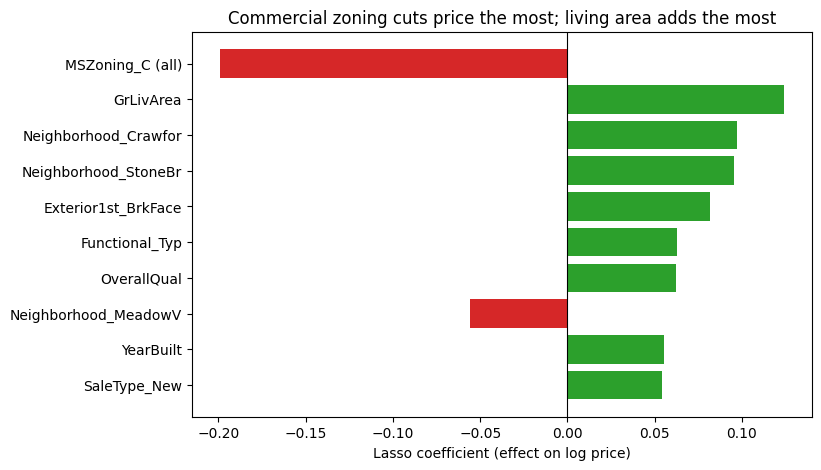

In [37]:
# 10 biggest effects by size, biggest on top; green raises price, red lowers it
top = coefs[coefs.abs().sort_values().index].tail(10)
colors = ["tab:green" if v > 0 else "tab:red" for v in top.values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Commercial zoning cuts price the most; living area adds the most")
ax.set_xlabel("Lasso coefficient (effect on log price)")
plt.show()

**What I see**
- Biggest effect: commercial zoning (MSZoning_C), about -18% price. It's based on only a handful of houses, so treat it with care.
- Biggest positive: living area. About +500 sq ft means about +13% price.
- Neighbourhood matters: Crawfor and StoneBr about +10%, MeadowV about -5%.
- OverallQual is only 7th here despite the highest correlation (0.79), because related quality columns share its effect.
- Number features (per 1 std) and categories (yes/no) are in different units, so the bars are only roughly comparable.

**Feature engineering** (summed features, logged skewed inputs) was tested in analysis.ipynb. Neither beat the 0.1114 target set in advance, so the final model stays Lasso on the original features.